In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
file_path = 'mhrd.csv'
data = pd.read_csv(file_path)

In [3]:
# Initial Data Exploration
print("Dataset Head:")
print(data.head())

Dataset Head:
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel
0   25         130           80  15.0      98.0         86  high risk
1   35         140           90  13.0      98.0         70  high risk
2   29          90           70   8.0     100.0         80  high risk
3   30         140           85   7.0      98.0         70  high risk
4   35         120           60   6.1      98.0         76   low risk


In [4]:
print("\nDataset Description:")
print(data.describe())


Dataset Description:
               Age   SystolicBP  DiastolicBP           BS     BodyTemp  \
count  1014.000000  1014.000000  1014.000000  1014.000000  1014.000000   
mean     29.871795   113.198225    76.460552     8.725986    98.665089   
std      13.474386    18.403913    13.885796     3.293532     1.371384   
min      10.000000    70.000000    49.000000     6.000000    98.000000   
25%      19.000000   100.000000    65.000000     6.900000    98.000000   
50%      26.000000   120.000000    80.000000     7.500000    98.000000   
75%      39.000000   120.000000    90.000000     8.000000    98.000000   
max      70.000000   160.000000   100.000000    19.000000   103.000000   

         HeartRate  
count  1014.000000  
mean     74.301775  
std       8.088702  
min       7.000000  
25%      70.000000  
50%      76.000000  
75%      80.000000  
max      90.000000  


In [5]:
print("\nData Types:")
print(data.dtypes)


Data Types:
Age              int64
SystolicBP       int64
DiastolicBP      int64
BS             float64
BodyTemp       float64
HeartRate        int64
RiskLevel       object
dtype: object


In [6]:
print(f"\nShape of Dataset: {data.shape}")


Shape of Dataset: (1014, 7)


In [7]:
print("\nMissing Values:")
print(data.isnull().sum())


Missing Values:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [8]:
# Data Cleaning
# Detect and handle duplicates
# duplicates = data.duplicated().sum()
# if duplicates > 0:
#     data = data.drop_duplicates()
#     print(f"\nRemoved {duplicates} duplicate rows.")

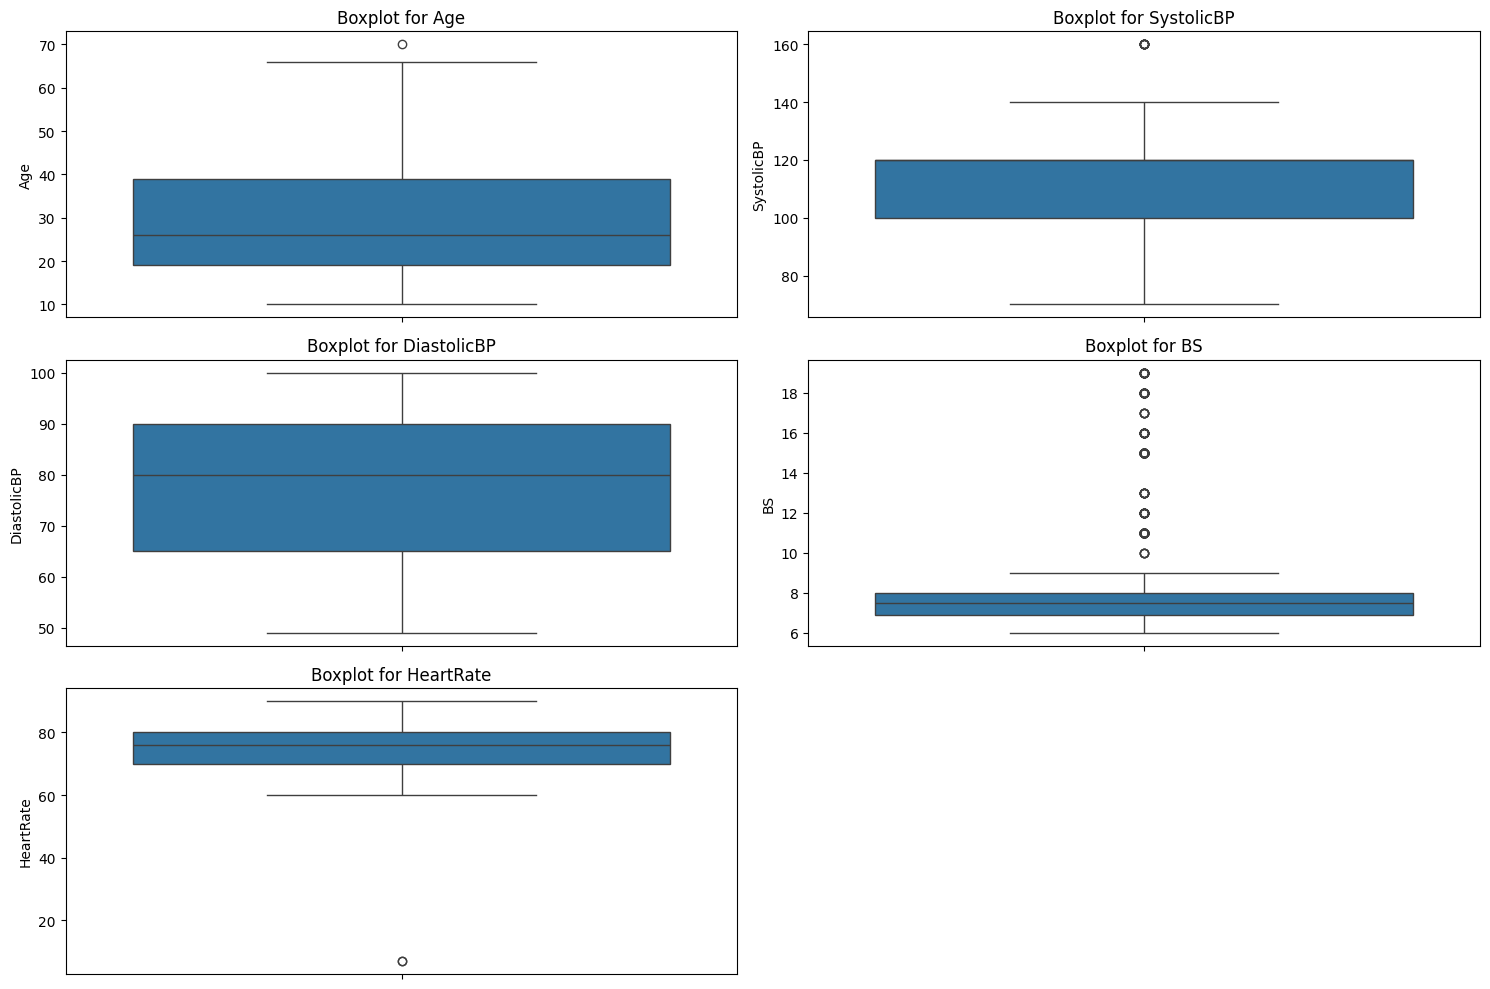

In [9]:
# Boxplots for Outlier Detection
numeric_columns = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

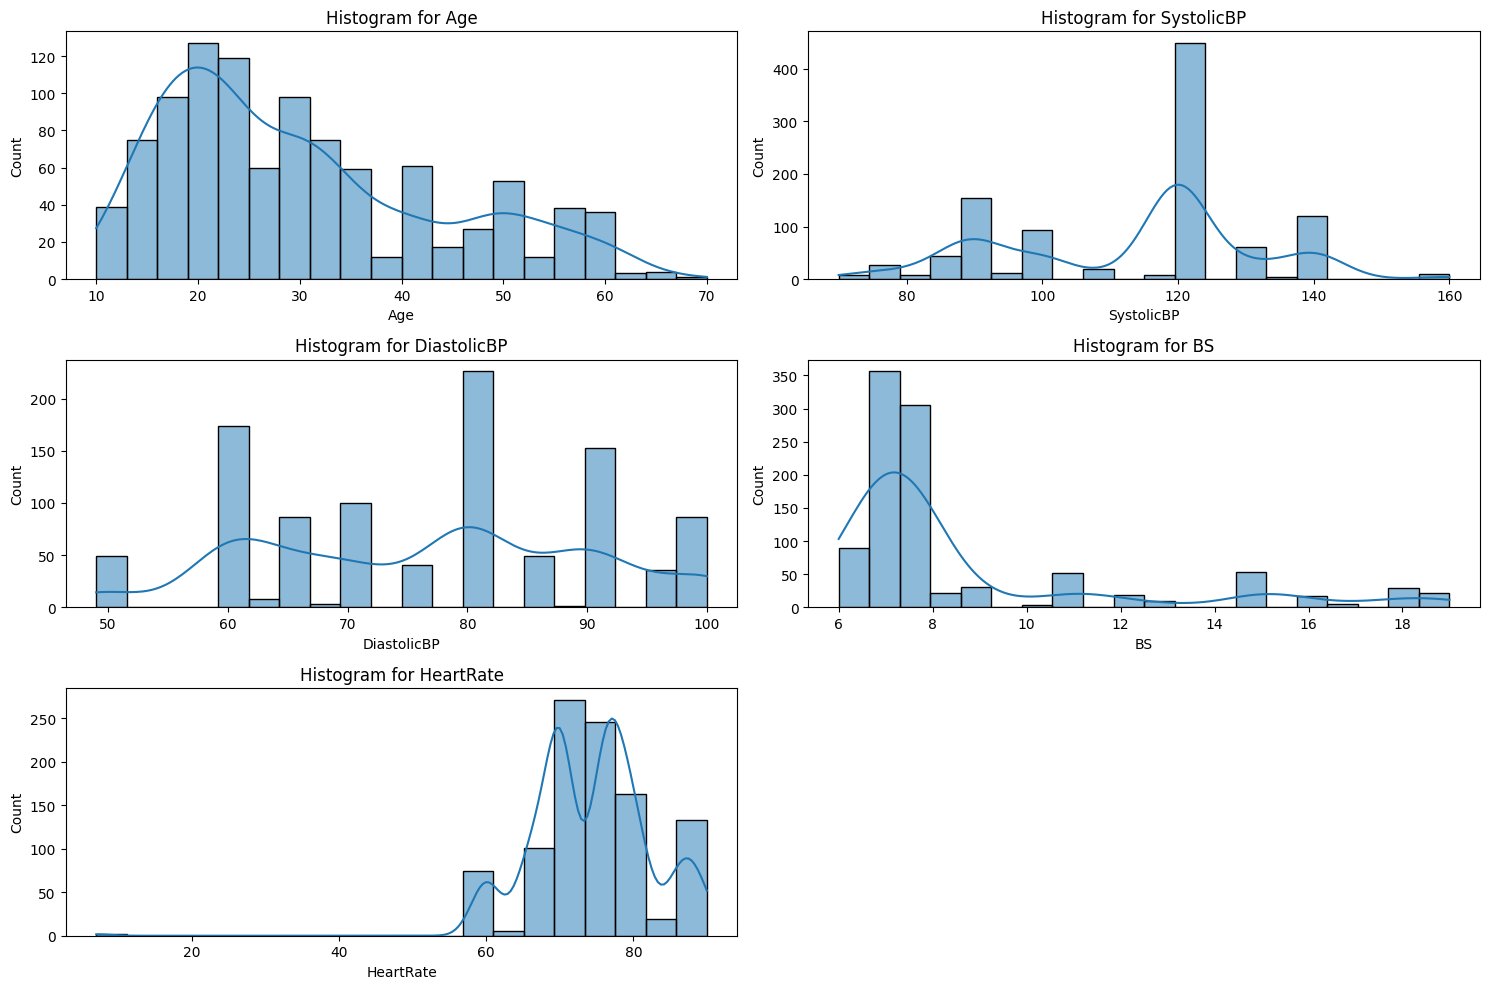

In [10]:
# Histograms for Distribution
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 2, i + 1)
    sns.histplot(data[col], kde=True, bins=20)
    plt.title(f'Histogram for {col}')
plt.tight_layout()
plt.show()

In [11]:
# Handle Outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [12]:
for col in numeric_columns:
    data = remove_outliers_iqr(data, col)

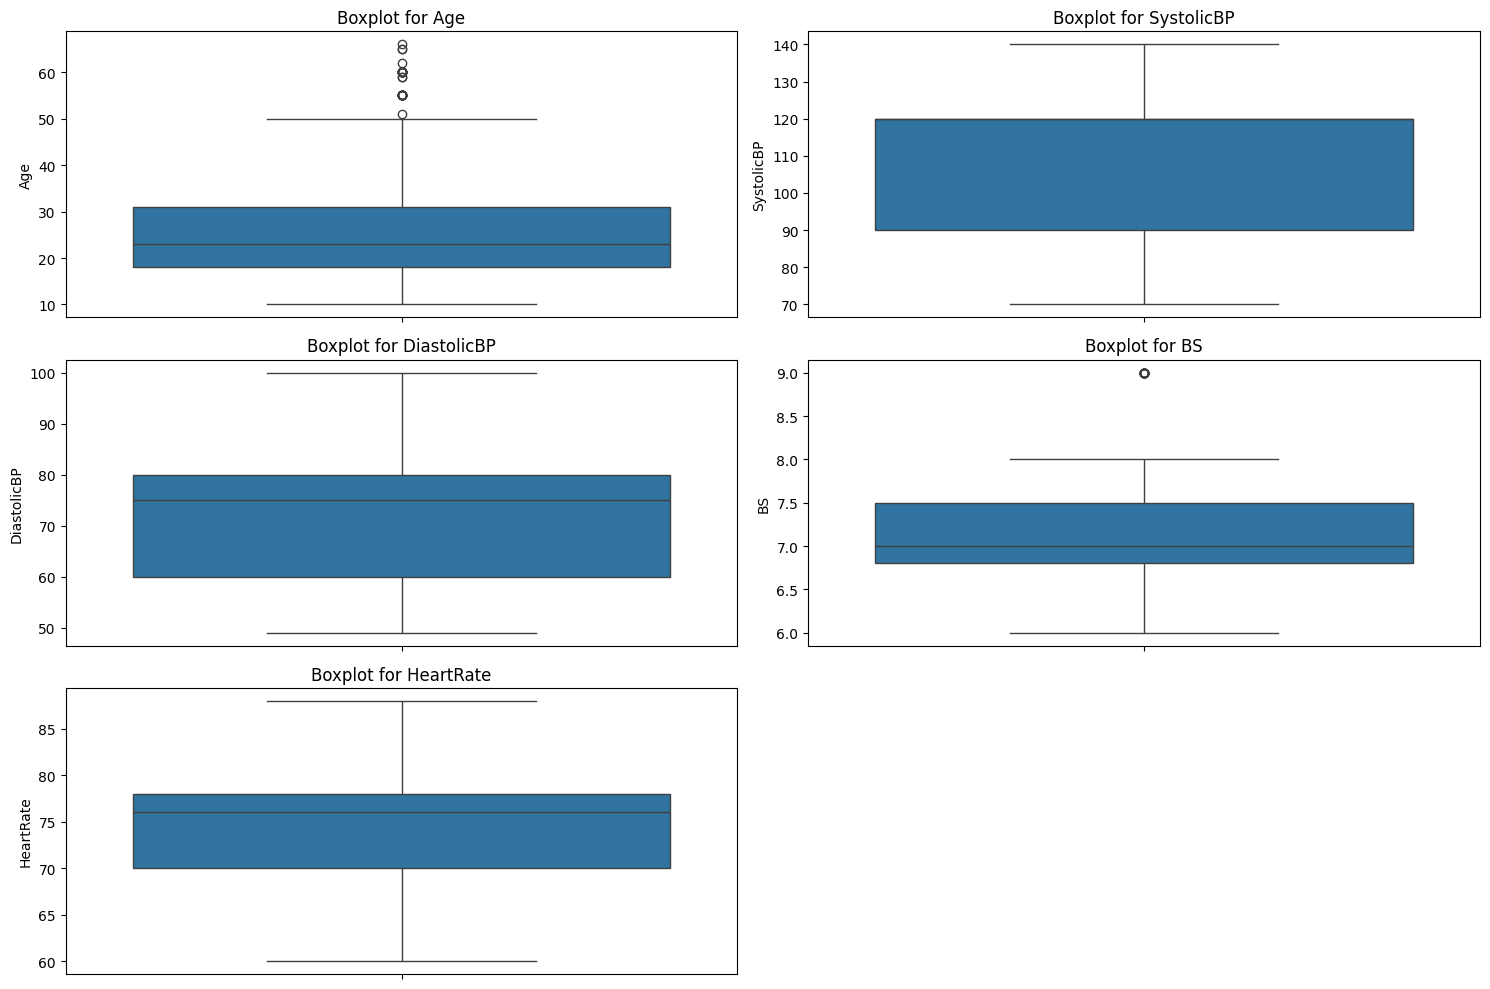

In [13]:
# Boxplots for Outlier Detection
numeric_columns = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'HeartRate']
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_columns):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data[col])
    plt.title(f'Boxplot for {col}')
plt.tight_layout()
plt.show()

In [14]:
# Check for missing values after outlier removal
print("\nMissing Values After Cleaning:")
print(data.isnull().sum())



Missing Values After Cleaning:
Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64


In [15]:
data.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
2,29,90,70,8.00,100.0,80,high risk
3,30,140,85,7.00,98.0,70,high risk
4,35,120,60,6.10,98.0,76,low risk
5,23,140,80,7.01,98.0,70,high risk
6,23,130,70,7.01,98.0,78,mid risk


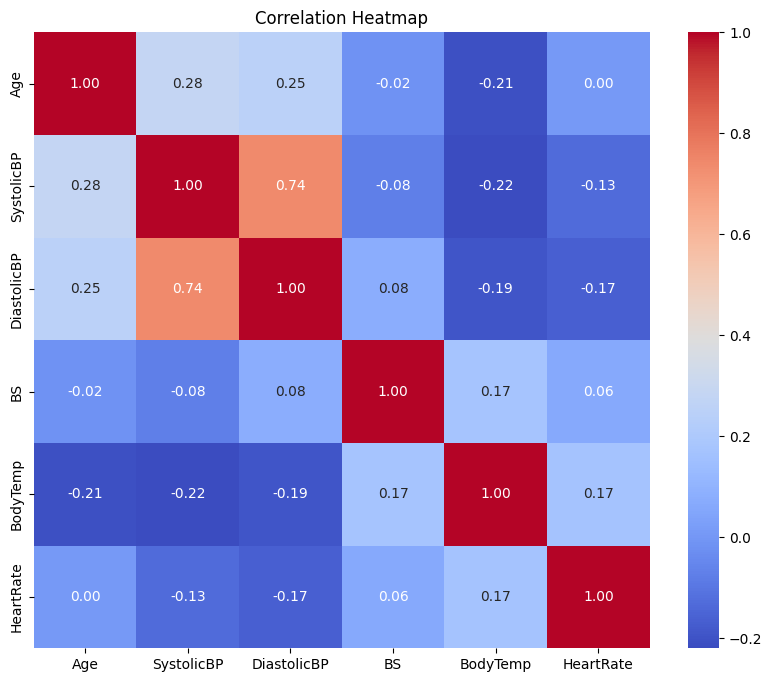

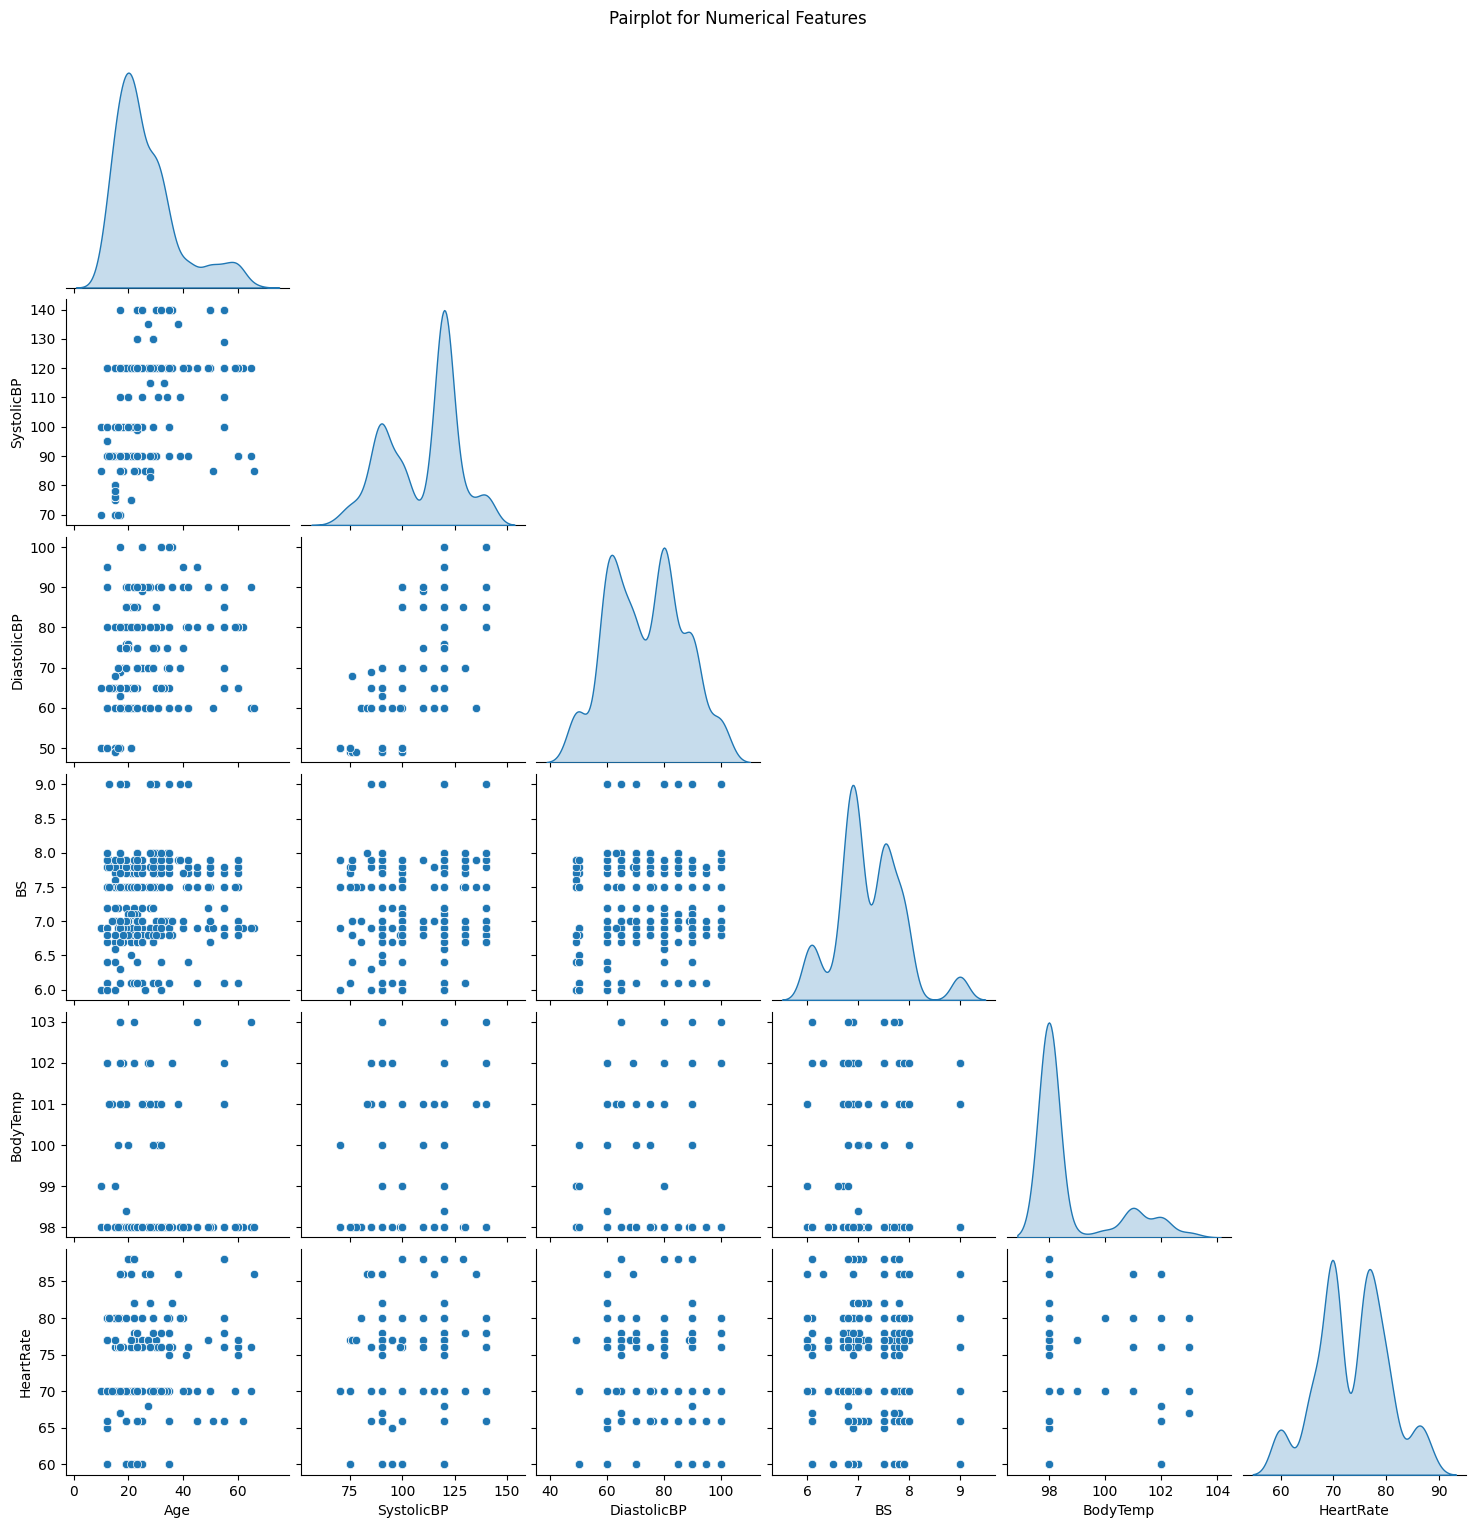

In [16]:
# Correlation Analysis
numeric_columns = ['Age', 'SystolicBP', 'DiastolicBP', 'BS','BodyTemp', 'HeartRate']
plt.figure(figsize=(10, 8))
correlation_matrix = data[numeric_columns].corr()  # Correlation matrix for numerical columns
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Correlation Heatmap")
plt.show()

# Pairplot for relationships (optional for small datasets)
sns.pairplot(data[numeric_columns], diag_kind='kde', corner=True)
plt.suptitle("Pairplot for Numerical Features", y=1.02)
plt.show()

In [17]:
# Encode Target Variable
data['RiskLevel'] = data['RiskLevel'].map({'low risk': 0, 'mid risk': 1, 'high risk': 2})
print("\nTarget Variable Distribution After Encoding:")
print(data['RiskLevel'].value_counts())


Target Variable Distribution After Encoding:
RiskLevel
0    399
1    304
2     98
Name: count, dtype: int64


In [18]:
# Split Dataset into Training and Testing Sets
from sklearn.model_selection import train_test_split, cross_val_score
X = data[numeric_columns]
y = data['RiskLevel']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [19]:
print(f"\nTraining Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")
print("Target Distribution in Training Set:")
print(y_train.value_counts())
print("Target Distribution in Testing Set:")
print(y_test.value_counts())


Training Set Shape: (560, 6)
Testing Set Shape: (241, 6)
Target Distribution in Training Set:
RiskLevel
0    279
1    213
2     68
Name: count, dtype: int64
Target Distribution in Testing Set:
RiskLevel
0    120
1     91
2     30
Name: count, dtype: int64


In [20]:
# Model Development and Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, multi_class='ovr'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(random_state=42, probability=True)
}


Training and Evaluating: Random Forest


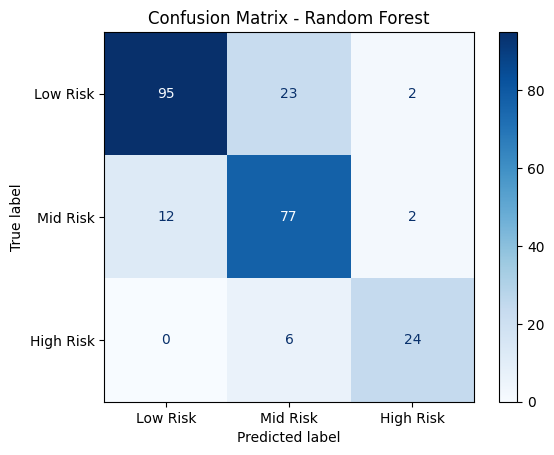

Classification Report for Random Forest:
              precision    recall  f1-score   support

    Low Risk       0.89      0.79      0.84       120
    Mid Risk       0.73      0.85      0.78        91
   High Risk       0.86      0.80      0.83        30

    accuracy                           0.81       241
   macro avg       0.82      0.81      0.82       241
weighted avg       0.82      0.81      0.81       241


Training and Evaluating: Logistic Regression


C:\Users\visha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\visha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\visha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\visha\AppD

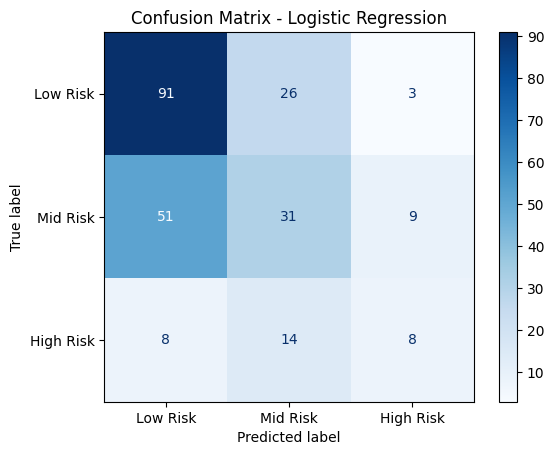

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

    Low Risk       0.61      0.76      0.67       120
    Mid Risk       0.44      0.34      0.38        91
   High Risk       0.40      0.27      0.32        30

    accuracy                           0.54       241
   macro avg       0.48      0.46      0.46       241
weighted avg       0.52      0.54      0.52       241


Training and Evaluating: K-Nearest Neighbors


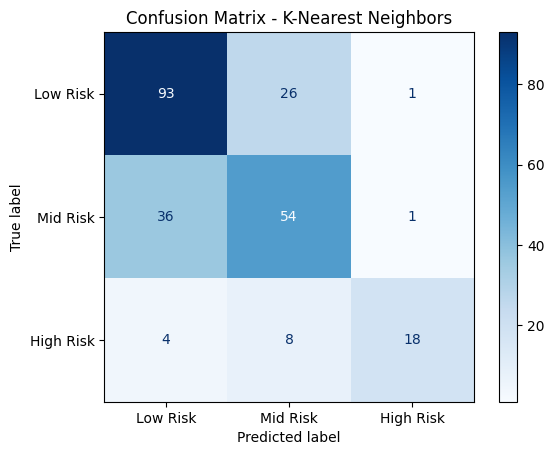

Classification Report for K-Nearest Neighbors:
              precision    recall  f1-score   support

    Low Risk       0.70      0.78      0.74       120
    Mid Risk       0.61      0.59      0.60        91
   High Risk       0.90      0.60      0.72        30

    accuracy                           0.68       241
   macro avg       0.74      0.66      0.69       241
weighted avg       0.69      0.68      0.68       241


Training and Evaluating: Support Vector Machine


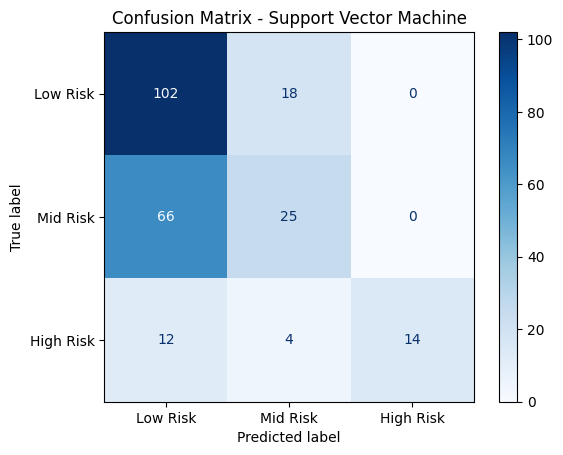

Classification Report for Support Vector Machine:
              precision    recall  f1-score   support

    Low Risk       0.57      0.85      0.68       120
    Mid Risk       0.53      0.27      0.36        91
   High Risk       1.00      0.47      0.64        30

    accuracy                           0.59       241
   macro avg       0.70      0.53      0.56       241
weighted avg       0.61      0.59      0.55       241



In [21]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
evaluation_results = {}
for model_name, model in models.items():
    print(f"\nTraining and Evaluating: {model_name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Cross-Validation for Robustness
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')

    # Metrics
    report = classification_report(y_test, y_pred, target_names=['Low Risk', 'Mid Risk', 'High Risk'])
    cm = confusion_matrix(y_test, y_pred)
    evaluation_results[model_name] = {
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "cv_accuracy_mean": cv_scores.mean(),
        "cv_accuracy_std": cv_scores.std()
    }

    # Confusion Matrix
    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low Risk', 'Mid Risk', 'High Risk'])
    cmd.plot(cmap='Blues')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    # Print Detailed Report
    print(f"Classification Report for {model_name}:\n{report}")

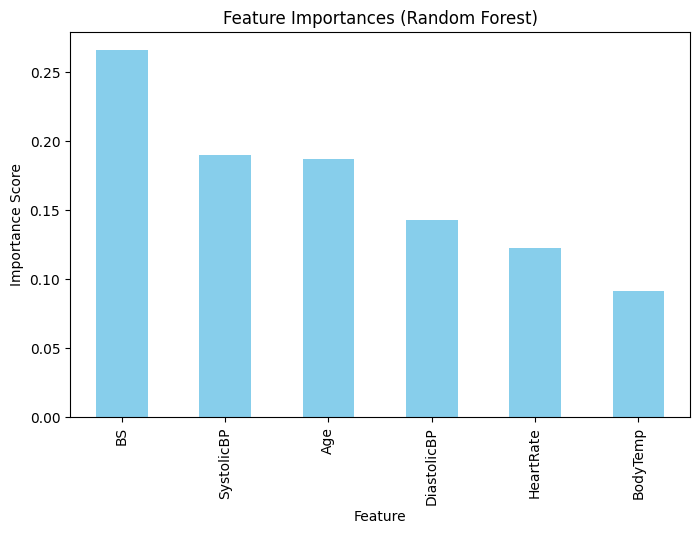

In [22]:
# Feature Importance (Random Forest Example)
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
feature_importances = pd.Series(rf_model.feature_importances_, index=numeric_columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feature_importances.plot(kind='bar', color='skyblue')
plt.title("Feature Importances (Random Forest)")
plt.ylabel("Importance Score")
plt.xlabel("Feature")
plt.show()

In [23]:
# Summary of Results
print("\nSummary of Evaluation Results:")
for model_name, metrics in evaluation_results.items():
    print(f"\n{model_name}:")
    print(f"  Cross-Validation Accuracy: {metrics['cv_accuracy_mean']:.4f} ± {metrics['cv_accuracy_std']:.4f}")
    print(f"  Accuracy (Test): {metrics['classification_report']['accuracy']:.4f}")
    print(f"  Precision (Avg): {metrics['classification_report']['weighted avg']['precision']:.4f}")
    print(f"  Recall (Avg): {metrics['classification_report']['weighted avg']['recall']:.4f}")
    print(f"  F1-Score (Avg): {metrics['classification_report']['weighted avg']['f1-score']:.4f}")


Summary of Evaluation Results:

Random Forest:
  Cross-Validation Accuracy: 0.7911 ± 0.0268
  Accuracy (Test): 0.8133
  Precision (Avg): 0.8231
  Recall (Avg): 0.8133
  F1-Score (Avg): 0.8150

Logistic Regression:
  Cross-Validation Accuracy: 0.5911 ± 0.0428
  Accuracy (Test): 0.5394
  Precision (Avg): 0.5167
  Recall (Avg): 0.5394
  F1-Score (Avg): 0.5200

K-Nearest Neighbors:
  Cross-Validation Accuracy: 0.6589 ± 0.0385
  Accuracy (Test): 0.6846
  Precision (Avg): 0.6919
  Recall (Avg): 0.6846
  F1-Score (Avg): 0.6835

Support Vector Machine:
  Cross-Validation Accuracy: 0.6000 ± 0.0397
  Accuracy (Test): 0.5851
  Precision (Avg): 0.6075
  Recall (Avg): 0.5851
  F1-Score (Avg): 0.5546


In [24]:
import random
import math

class DecisionTree:
    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.tree = None

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, depth=0)

    def predict(self, X):
        return [self._predict_single(x, self.tree) for x in X]

    def _build_tree(self, X, y, depth):
        if len(set(y)) == 1 or (self.max_depth is not None and depth >= self.max_depth):
            return {'value': self._most_common_label(y)}

        feature, threshold = self._best_split(X, y)
        if feature is None:
            return {'value': self._most_common_label(y)}

        left_indices = [i for i in range(len(X)) if X[i][feature] <= threshold]
        right_indices = [i for i in range(len(X)) if X[i][feature] > threshold]

        left_tree = self._build_tree([X[i] for i in left_indices], [y[i] for i in left_indices], depth + 1)
        right_tree = self._build_tree([X[i] for i in right_indices], [y[i] for i in right_indices], depth + 1)

        return {'feature': feature, 'threshold': threshold, 'left': left_tree, 'right': right_tree}

    def _best_split(self, X, y):
        best_gain = 0
        best_feature, best_threshold = None, None
        for feature in range(len(X[0])):
            thresholds = set([x[feature] for x in X])
            for threshold in thresholds:
                gain = self._information_gain(X, y, feature, threshold)
                if gain > best_gain:
                    best_gain, best_feature, best_threshold = gain, feature, threshold
        return best_feature, best_threshold

    def _information_gain(self, X, y, feature, threshold):
        left_indices = [i for i in range(len(X)) if X[i][feature] <= threshold]
        right_indices = [i for i in range(len(X)) if X[i][feature] > threshold]
        if not left_indices or not right_indices:
            return 0
        left_y = [y[i] for i in left_indices]
        right_y = [y[i] for i in right_indices]
        return self._entropy(y) - (len(left_y) / len(y) * self._entropy(left_y) + len(right_y) / len(y) * self._entropy(right_y))

    def _entropy(self, y):
        counts = {label: y.count(label) for label in set(y)}
        return -sum((count / len(y)) * math.log2(count / len(y)) for count in counts.values())

    def _most_common_label(self, y):
        return max(set(y), key=y.count)

    def _predict_single(self, x, tree):
        if 'value' in tree:
            return tree['value']
        feature, threshold = tree['feature'], tree['threshold']
        if x[feature] <= threshold:
            return self._predict_single(x, tree['left'])
        else:
            return self._predict_single(x, tree['right'])


class RandomForest:
    def __init__(self, n_estimators=10, max_depth=None):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.trees = []

    def fit(self, X, y):
        for _ in range(self.n_estimators):
            sample_indices = [random.randint(0, len(X) - 1) for _ in range(len(X))]
            X_sample = [X[i] for i in sample_indices]
            y_sample = [y[i] for i in sample_indices]
            tree = DecisionTree(max_depth=self.max_depth)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)

    def predict(self, X):
        tree_predictions = [tree.predict(X) for tree in self.trees]
        tree_predictions = list(zip(*tree_predictions))
        return [self._most_common_label(tree_pred) for tree_pred in tree_predictions]

    def _most_common_label(self, labels):
        return max(set(labels), key=labels.count)

if __name__ == "__main__":
    
    X_train = [
        [25, 130, 80, 15, 98, 86],
        [35, 140, 90, 13, 98, 70],
        [29, 90, 70, 8, 100, 80],
        [30, 140, 85, 7, 98, 70],
        [35, 120, 60, 6.1, 98, 76],
        [23, 140, 80, 7.01, 98, 70],
        [23, 130, 70, 7.01, 98, 78],
        [35, 85, 60, 11, 102, 86],
        [32, 120, 90, 6.9, 98, 70],
        [42, 130, 80, 18, 98, 70],
        [23, 90, 60, 7.01, 98, 76],
        [19, 120, 80, 7, 98, 70],
        [25, 110, 89, 7.01, 98, 77],
        [20, 120, 75, 7.01, 100, 70],
        [48, 120, 80, 11, 98, 88],
        [15, 120, 80, 7.01, 98, 70],
    ]

    # Labels (RiskLevel)
    y_train = [
        "high risk", "high risk", "high risk", "high risk",
        "low risk", "high risk", "mid risk", "high risk",
        "mid risk", "high risk", "low risk", "mid risk",
        "low risk", "mid risk", "mid risk", "low risk"
    ]

    # Test Data
    X_test = [
        [25, 130, 80, 15, 98, 86],  # Test 1
        [35, 120, 60, 6.1, 98, 76],   # Test 2
        [40, 140, 90, 12, 99, 85],  # Test 3
    ]

    # Train RandomForest
    forest = RandomForest(n_estimators=5, max_depth=3)
    forest.fit(X_train, y_train)

    # Predict Risk Levels
    predictions = forest.predict(X_test)
    print("Predictions:", predictions)


Predictions: ['high risk', 'low risk', 'high risk']


In [25]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
import pickle

# Assume you have training data: X_train and y_train
# Train a Random Forest model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Save the trained model to a .pkl file
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)

print("Model saved as random_forest_model.pkl")


Model saved as random_forest_model.pkl
